# Exploratory Data Analysis (EDA) Tutorial  

In this walk-through session, we will practice **Exploratory Data Analysis (EDA)** on a salary dataset.

---

## Learning outcomes
By the end of this notebook, you should be able to:
- Load CSV files into pandas DataFrames
- Check basic dataset health (rows, columns, missing values, unique values)
- Do **Univariate** analysis (one variable)
- Do **Bivariate** analysis (relationship between two variables)
- Do a simple **Multivariate** view (a few variables together) and discuss patterns

---

**The goal of this step is to become confident that the data set is ready to be used in a machine learning algorithm**.

---

### Dataset (your class files from Spectrum)
- `salary_cleaned.csv` — main table (includes Salary and core demographics)
- `xtra_info.csv` — extra columns (job title, state, etc.)

---

### References:

[01]. A Simple Tutorial on Exploratory Data Analysis. https://www.kaggle.com/code/spscientist/a-simple-tutorial-on-exploratory-data-analysis#A-Simple-Tutorial-on-Exploratory-Data-Analysis

## Overview

We will analyze a salary dataset using EDA to understand:
- What the data contains (columns + data types)
- How salary is distributed overall
- How salary patterns change across groups (e.g., gender, education, age, experience)

We will combine two CSV files:
- `salary_cleaned.csv` (main salary information)
- `xtra_info.csv` (extra background information)

### Discussions
Before we start coding: **what do you expect the salary distribution to look like?**  
- Symmetric (bell-shaped) or skewed?  
- Are outliers likely? Why?

## Description

Goal: Explore how **salary** changes with factors such as:
- Age group
- Years of experience
- Education level
- Job title / state (if available)

Remember: **EDA shows patterns** in the dataset. It does **not** prove causation.

## Import Libraries

We use:
- **numpy** for basic numeric utilities
- **pandas** for DataFrame operations (load, filter, group, summary)

In [ ]:
# Import libraries
import numpy as np
import pandas as pd

## Mount Google Drive into Colab

In Google Colab, your files in Google Drive are not automatically available.
Mounting Drive lets Colab read your CSV files from your Drive folders.

In [ ]:
# Mount Google Drive into Colab. Colab runs on a cloud VM. Your Drive is not available by default. When you run it, Colab will show an authentication link and ask you to authorize.
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Load CSV Files into DataFrames

Next, we load the two CSV files using `pd.read_csv()`.

If you get a *FileNotFoundError*, check the folder path in Google Drive (spelling + space + capitalization).

To start exploring your data, you’ll need to start by actually loading in your data.

In [ ]:
# Load CSV files into DataFrames (update the path if your folder name is different)
df_salary_cleaned = pd.read_csv('/content/drive/MyDrive/WIA1007/Dataset/salary_cleaned.csv') #load the csv dataset into a 'dataframe' df
df_xtra_info = pd.read_csv('/content/drive/MyDrive/WIA1007/Dataset/xtra_info.csv') #load the csv dataset into a 'dataframe' df

## Print number of rows in each DataFrame

This is a quick sanity check:
- Do both tables have the expected number of rows?
- If we combine them, will the row counts still make sense?

In [ ]:
print ('\nNo of rows in df_salary_cleaned DataFrame:')
# Print number of rows in df_salary_cleaned DataFrame
print(len(df_salary_cleaned))

print ('\nNo of rows in df_xtra_info DataFrame:')
# Print number of rows in df_xtra_info DataFrame
print(len(df_xtra_info))


No of rows in df_salary_cleaned DataFrame:
28012

No of rows in df_xtra_info DataFrame:
13404


## Combine both DataFrames horizontally (add columns)

We use `pd.concat(..., axis=1)` to place the extra-info columns next to the salary columns.

Note:
`concat(axis=1)` assumes the rows are in the **same order** in both DataFrames.
If the rows are not aligned, the correct approach is usually a `merge` using a key like `USERID`.
(Here, we keep your approach and later remove `USERID`.)

In [ ]:
# Combine both DataFrames horizontally (add columns)
df_master = pd.concat([df_salary_cleaned,df_xtra_info],axis=1)

print ('\nAfter combine both DataFrames:')
# Print number of rows in df_master DataFrame
print(len(df_master))


After combine both DataFrames:
28012


## Print rows in `df_master`

We print a few rows to confirm:
- The combine worked (we see columns from both datasets)
- The column names look correct
- The values look reasonable

In [ ]:
# Print top 5 rows in df_master DataFrame
df_master.head()

,USERID,Age,Industry,Job title,Salary,Compensation,Country,State,City,Overall years of experience,Years of experience in current job,Education level,Gender,Race,Salary_USD,Compensation_USD,USERID,CGPA,Salary_month_USD,Special Bonus_GBP
0,0,25-34,Education (Higher Education),Research and Instruction Librarian,55000.0,0.0,United States,Massachusetts,Boston,5-7 years,5-7 years,Master's degree,Woman,White,55000.0,0.0,8683.0,2.990627,4583.333333,2437.0
1,1,25-34,Computing or Tech,Change & Internal Communications Manager,54600.0,4000.0,United Kingdom,Unknown,Cambridge,8 - 10 years,5-7 years,College degree,Non-binary,White,68250.0,5000.0,3880.0,2.288131,5166.666667,740.0
2,2,25-34,"Accounting, Banking & Finance",Marketing Specialist,34000.0,2000.0,US,Tennessee,Chattanooga,2 - 4 years,2 - 4 years,College degree,Woman,White,34000.0,2000.0,8898.0,3.903324,5000.000000,3806.0
3,3,25-34,Nonprofits,Program Manager,62000.0,3000.0,USA,Wisconsin,Milwaukee,8 - 10 years,5-7 years,College degree,Woman,White,62000.0,3000.0,4441.0,2.470852,9333.333333,4691.0
4,4,25-34,"Accounting, Banking & Finance",Accounting Manager,60000.0,7000.0,US,South Carolina,Greenville,8 - 10 years,5-7 years,College degree,Woman,White,60000.0,7000.0,7537.0,3.559457,3750.000000,4580.0


## Analyzing each column

A good first step in EDA is to look at:
- Column names
- Which columns are numeric vs categorical
- Any ID columns that should not be used for analysis

In [ ]:
# USERID is an identifier (not a feature). We drop it to avoid using it in analysis.
df_master.columns # show columns before dropping
df_master = df_master.drop(columns='USERID')
df_master.columns # verify USERID is removed

Index(['Age', 'Industry', 'Job title', 'Salary', 'Compensation', 'Country',
       'State', 'City', 'Overall years of experience',
       'Years of experience in current job', 'Education level', 'Gender',
       'Race', 'Salary_USD', 'Compensation_USD', 'CGPA', 'Salary_month_USD',
       'Special Bonus_GBP'],
      dtype='object')

## Analyzing each feature

We count **unique values** in each column:
- Columns with few unique values (e.g., Gender) are usually **categorical**
- Columns with many unique values (e.g., Salary) are usually **numeric**

In [ ]:
# Count unique values in each column (helps identify categorical vs numeric features)
for feature in df_master.columns:
  len_feature = df_master[feature].nunique()
  print(f'{feature}: {len_feature}')

Age: 7
Industry: 1216
Job title: 14344
Salary: 3342
Compensation: 423
Country: 361
State: 138
City: 4797
Overall years of experience: 8
Years of experience in current job: 8
Education level: 6
Gender: 5
Race: 52
Salary_USD: 4021
Compensation_USD: 594
CGPA: 13403
Salary_month_USD: 1791
Special Bonus_GBP: 4673


## Create empty small vs large lists (placeholders)

We will store column names in two groups:
- `feature_small`: columns with **<= 10** unique values (good for bar charts)
- `feature_large`: columns with **> 10** unique values (often numeric or high-cardinality)

In [ ]:
# (Optional) Create empty lists for later use
feature_small = []
feature_large = []

# Still printing unique counts (same idea as above)
for feature in df_master.columns:
  x = df_master[feature].nunique()
  print(f'{feature}: {x}')

Age: 7
Industry: 1216
Job title: 14344
Salary: 3342
Compensation: 423
Country: 361
State: 138
City: 4797
Overall years of experience: 8
Years of experience in current job: 8
Education level: 6
Gender: 5
Race: 52
Salary_USD: 4021
Compensation_USD: 594
CGPA: 13403
Salary_month_USD: 1791
Special Bonus_GBP: 4673


## Split into small vs large lists

This step automatically separates columns into:
- low-cardinality (small) features
- high-cardinality (large) features

This helps us decide what kind of plot is suitable for each feature.

In [ ]:
# This code splits into small and large lists and prints the lists
feature_small = []
feature_large = []

for feature in df_master.columns:
  len_feature = df_master[feature].nunique()

  if (len_feature <= 10 ):
    feature_small.append([feature, len_feature])
  else:
    feature_large.append([feature, len_feature])

print('----Feature small----')
for item in feature_small:
  print(item)

print('\n-----Feature large------')
for item in feature_large:
  print(item)


----Feature small----
['Age', 7]
['Overall years of experience', 8]
['Years of experience in current job', 8]
['Education level', 6]
['Gender', 5]

-----Feature large------
['Industry', 1216]
['Job title', 14344]
['Salary', 3342]
['Compensation', 423]
['Country', 361]
['State', 138]
['City', 4797]
['Race', 52]
['Salary_USD', 4021]
['Compensation_USD', 594]
['CGPA', 13403]
['Salary_month_USD', 1791]
['Special Bonus_GBP', 4673]


## Part A — Univariate EDA (One variable at a time)

### Univariate for categorical columns
We use `value_counts()` to see how many samples belong to each category.

## Analyzing small categorical variables

For columns with few unique values, a **bar chart** is a good starting plot:
- What categories exist?
- Which categories are most common?
- Are there any rare categories (very few samples)?

**Discussions:** What do we observe in the plot, and what could explain it?

Age


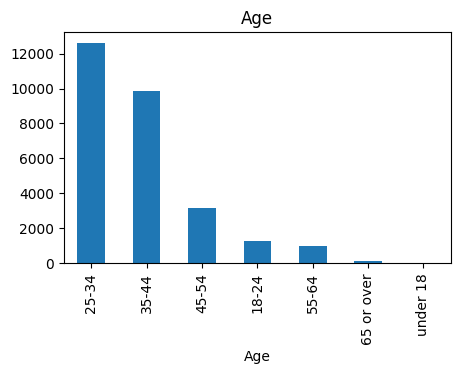

Overall years of experience


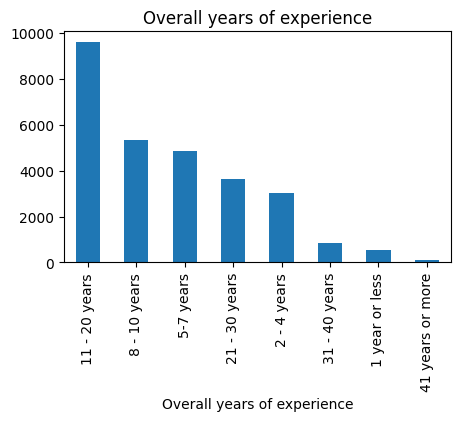

Years of experience in current job


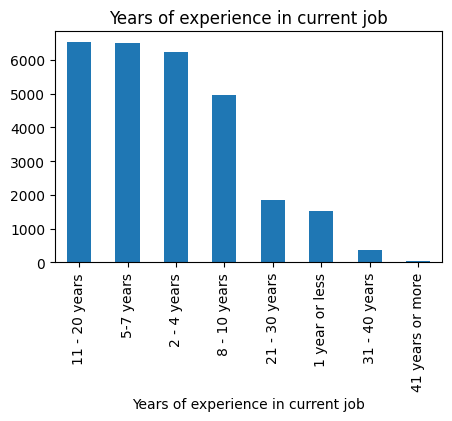

Education level


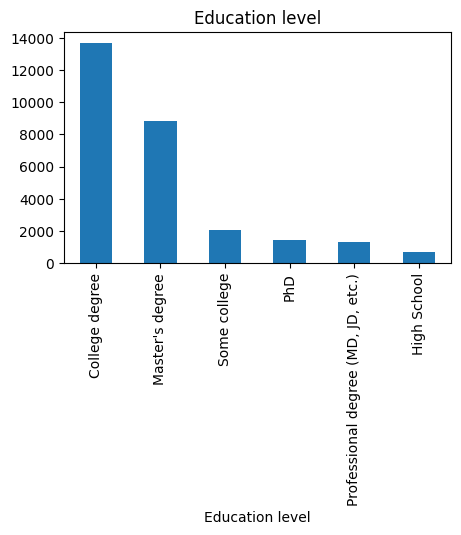

Gender


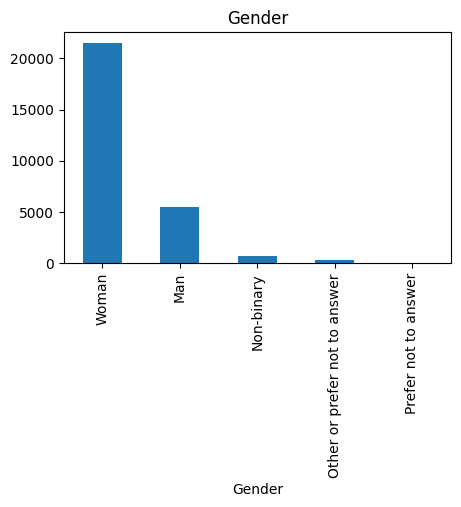

In [ ]:
import matplotlib.pyplot as plt

for item in feature_small:
  column_name = item[0]
  print(column_name)

  df_master[column_name].value_counts().plot(kind='bar',figsize=(5,3),title=column_name)
  plt.show()

## Using subplots to improve visualization

Instead of creating many separate plots, we can draw multiple bar charts in a grid (subplots).
This is easier to compare across variables.

Note: We limit to the first few columns to keep the figure readable.

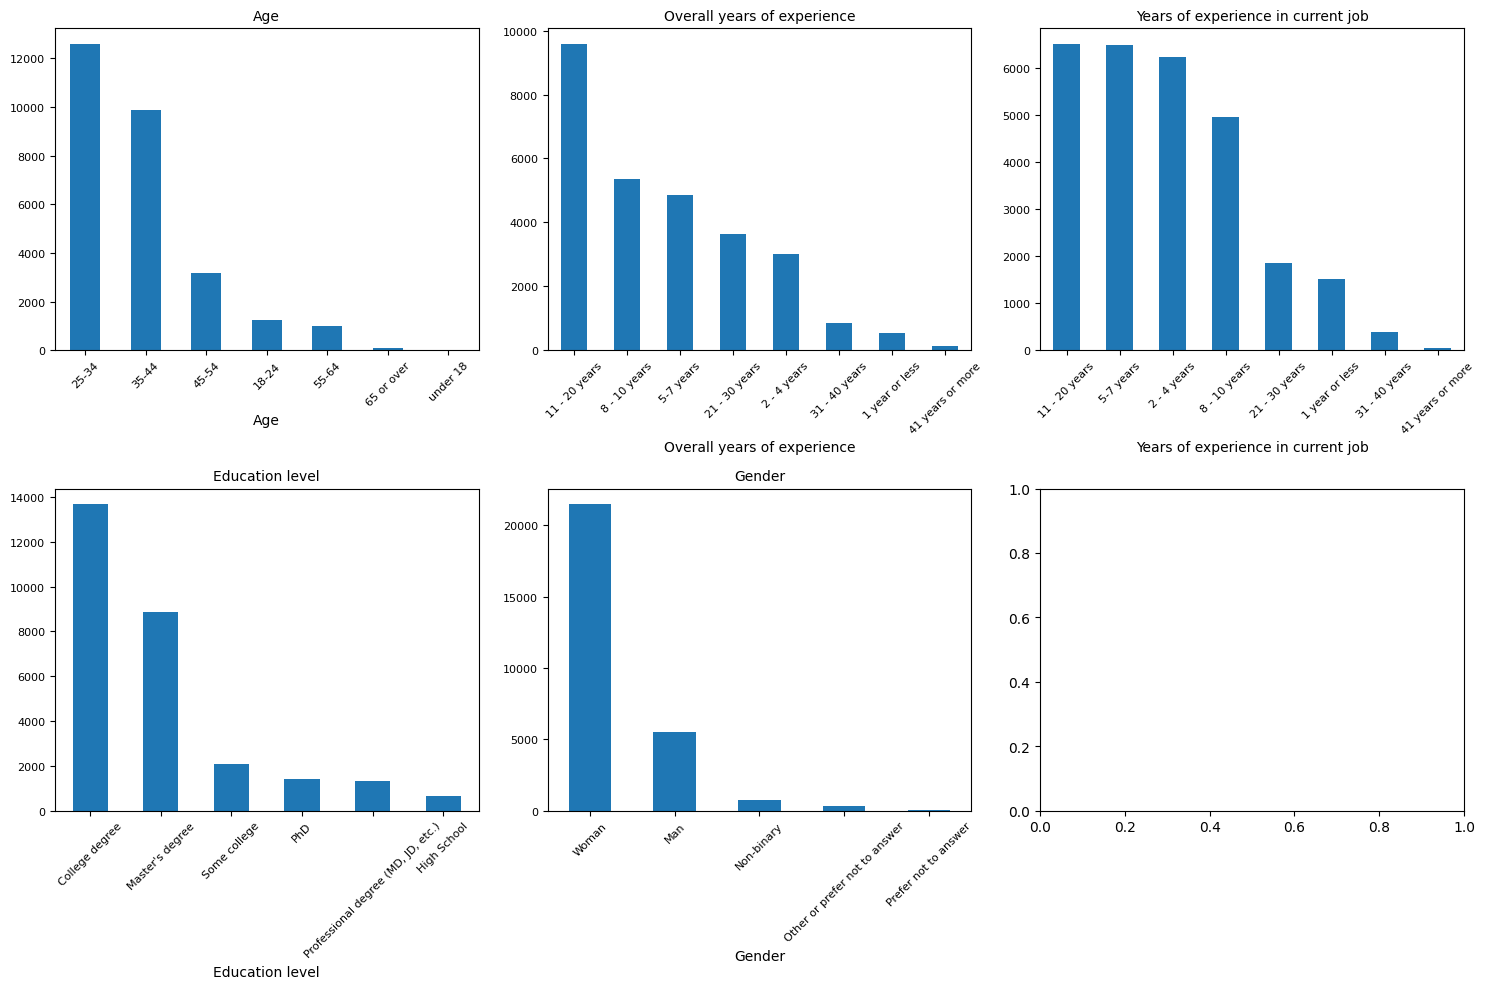

In [ ]:
import matplotlib.pyplot as plt

# Plot a few 'small' (low-unique) categorical columns using subplots
# We limit to the first 6 columns so the 2x3 grid does not overflow.
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for k, item in enumerate(feature_small[:6]):
  column_name = item[0]
  df_master[column_name].value_counts().plot(
      kind='bar', ax=axes[k], fontsize=8, rot=45
  )
  axes[k].set_title(column_name, fontsize=10)

plt.tight_layout()
plt.show()

## Part B — Bivariate EDA (Two variables)

### B1) Salary distribution by Gender (Histogram)

A histogram shows the **frequency** (count) of salary values in different ranges (bins).

What to observe:
- **Shape**: is the distribution skewed (common in salary data)?
- **Spread**: do salaries vary widely?
- **Outliers**: do you see a long right tail (very high salaries)?

Note: If one group’s histogram appears shifted higher/lower, this is an **EDA pattern** only.
It does **not** prove causation. Other variables (education, experience, job title, location) can affect salary.


## Analyzing the effect of gender on salary distribution

We will compare salary distributions:
- Overall salary histogram
- Salary histogram for women
- Salary histogram for men

After the plots, we will discuss:
- Are the distributions similar or different?
- Are there outliers?
- What might explain any differences (education, experience, job title, etc.)?

<Axes: >

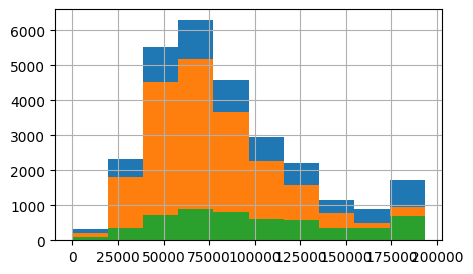

In [ ]:
# Plot salary histograms (overall and by gender)
# Note: when you plot multiple histograms on the same figure, they may overlap.
# Uncomment one line at a time if you want a cleaner view.

df_master['Salary'].hist(figsize=(5,3))
df_master[df_master['Gender']=='Woman']['Salary'].hist(figsize=(5,3))  # subset by gender
df_master[df_master['Gender']=='Man']['Salary'].hist(figsize=(5,3))

# -------------------------------------
# df_master['Salary'].hist(figsize=(5,3))
# plt.title("Salary Distribution (All)")
# plt.show()

# df_master[df_master['Gender']=='Woman']['Salary'].hist(figsize=(5,3))
# plt.title("Salary Distribution (Women)")
# plt.show()

# df_master[df_master['Gender']=='Man']['Salary'].hist(figsize=(5,3))
# plt.title("Salary Distribution (Men)")
# plt.show()

# ------------Box Plot (Salary Vs Gender) -------------------------

# import seaborn as sns
# import matplotlib.pyplot as plt

# sns.boxplot(x='Gender', y='Salary', data=df_master)
# plt.title('Salary Distribution by Gender (Boxplot)')
# plt.show()


### B2) Correlation inside each gender group (numeric columns only)
Correlation helps show relationships between numeric variables within each group.

In [ ]:
numerical_cols = df_master.select_dtypes(include=np.number).columns.tolist()

df_woman = df_master[df_master['Gender']=='Woman']
df_man = df_master[df_master['Gender']=='Man']

print("Numeric columns:", numerical_cols)

print("\nCorrelation (Women):")
display(df_woman[numerical_cols].corr())

print("\nCorrelation (Men):")
display(df_man[numerical_cols].corr())

Numeric columns: ['Salary', 'Compensation', 'Salary_USD', 'Compensation_USD', 'CGPA', 'Salary_month_USD', 'Special Bonus_GBP']

Correlation (Women):


,Salary,Compensation,Salary_USD,Compensation_USD,CGPA,Salary_month_USD,Special Bonus_GBP
Salary,1.000000,0.446363,0.954137,0.432546,0.004049,-0.009609,0.005901
Compensation,0.446363,1.000000,0.453474,0.992226,-0.005529,-0.013478,-0.005587
Salary_USD,0.954137,0.453474,1.000000,0.462607,0.000726,-0.009809,0.004753
Compensation_USD,0.432546,0.992226,0.462607,1.000000,-0.005687,-0.012716,-0.004463
CGPA,0.004049,-0.005529,0.000726,-0.005687,1.000000,0.002508,0.003476
Salary_month_USD,-0.009609,-0.013478,-0.009809,-0.012716,0.002508,1.000000,0.000857
Special Bonus_GBP,0.005901,-0.005587,0.004753,-0.004463,0.003476,0.000857,1.000000



Correlation (Men):


,Salary,Compensation,Salary_USD,Compensation_USD,CGPA,Salary_month_USD,Special Bonus_GBP
Salary,1.000000,0.470134,0.958438,0.450614,0.005384,0.013269,0.020659
Compensation,0.470134,1.000000,0.464778,0.986752,-0.018615,0.042800,0.004426
Salary_USD,0.958438,0.464778,1.000000,0.478285,0.008259,0.014590,0.019341
Compensation_USD,0.450614,0.986752,0.478285,1.000000,-0.018372,0.040179,0.003209
CGPA,0.005384,-0.018615,0.008259,-0.018372,1.000000,0.018007,0.009082
Salary_month_USD,0.013269,0.042800,0.014590,0.040179,0.018007,1.000000,0.012899
Special Bonus_GBP,0.020659,0.004426,0.019341,0.003209,0.009082,0.012899,1.000000


### B3) Mean salary by Education level (Women vs Men)
We compute mean salary by each education category and compare both groups side-by-side.

,Education_level,mean_woman,mean_man
0,Master's degree,83955.901357,103578.677603
1,College degree,77980.514118,100759.902722
2,PhD,96097.628391,119593.238095
3,Some college,64659.141489,91124.391597
4,High School,58720.541667,88295.623016
5,"Professional degree (MD, JD, etc.)",119303.720146,126788.188482


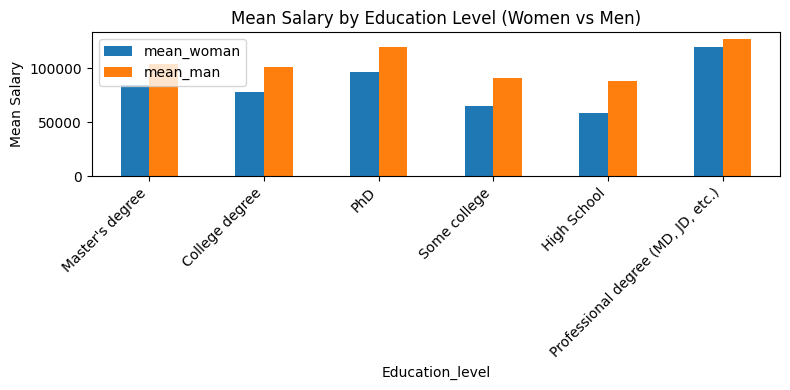

In [ ]:
edu_col = 'Education level'  # keeping your column naming

edu_levels = df_master[edu_col].dropna().unique()

records = []
for level in edu_levels:
  mean_w = df_woman[df_woman[edu_col] == level]['Salary'].mean()
  mean_m = df_man[df_man[edu_col] == level]['Salary'].mean()
  records.append([level, mean_w, mean_m])

salary_by_edu = pd.DataFrame(records, columns=['Education_level', 'mean_woman', 'mean_man'])
display(salary_by_edu)

salary_by_edu.set_index('Education_level')[['mean_woman','mean_man']].plot.bar(figsize=(8,4))
plt.title("Mean Salary by Education Level (Women vs Men)")
plt.ylabel("Mean Salary")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Question: How does salary vary across education, age, and experience?

Here we compute and plot:
- Mean salary by **education level** (women vs men)
- Mean salary by **experience** (women vs men)
- Mean salary by **age group** (women vs men)

### Discussions:
- Which groups have the highest/lowest mean salary?
- Are some groups small (few samples) and therefore unstable?

## Part C — Multivariate EDA (More than two variables)

### Grouped averages using multiple columns

We check grouped averages using multiple factors:
- Education level
- Age
- Overall years of experience

In [ ]:
group_cols = []
for col in ['Education level', 'Age', 'Overall years of experience']:
  if col in df_master.columns:
    group_cols.append(col)

if len(group_cols) == 0:
  print("None of ['Education level', 'Age', 'Overall years of experience'] were found.")
else:
  display(df_master.groupby(group_cols)['Salary'].mean().reset_index().head(10))

,Education level,Age,Overall years of experience,Salary
0,College degree,18-24,1 year or less,56847.684000
1,College degree,18-24,11 - 20 years,85850.000000
2,College degree,18-24,2 - 4 years,61349.634483
3,College degree,18-24,21 - 30 years,65000.000000
4,College degree,18-24,5-7 years,48582.708861
5,College degree,18-24,8 - 10 years,41482.333333
6,College degree,25-34,1 year or less,54013.442308
7,College degree,25-34,11 - 20 years,86591.564717
8,College degree,25-34,2 - 4 years,66150.943163
9,College degree,25-34,21 - 30 years,21149.666667


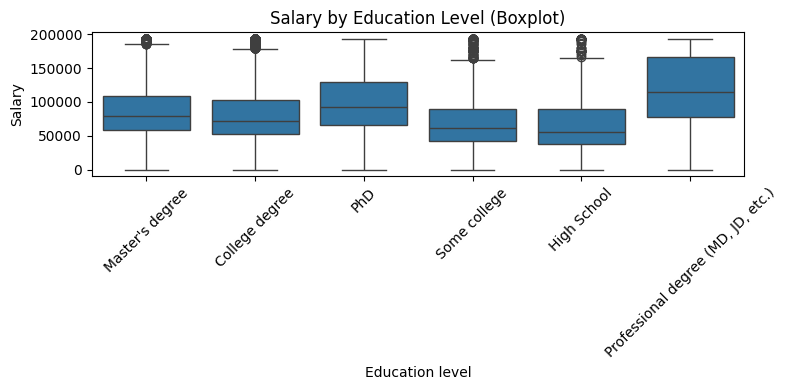

In [ ]:
import seaborn as sns

if 'Education level' in df_master.columns:
  plt.figure(figsize=(8,4))
  sns.boxplot(x='Education level', y='Salary', data=df_master)
  plt.title('Salary by Education Level (Boxplot)')
  plt.xticks(rotation=45)
  plt.tight_layout()
  plt.show()
else:
  print("Education level column not found.")

### C1) Reusable function: Compare mean salary by category (Women vs Men)

With:
- Overall years of experience
- Age

(We keep your function and call it for two categories.)

In [ ]:
def analysis_by_category(category):
  levels = df_master[category].dropna().unique()

  rows = []
  for level in levels:
    mean_w = df_woman[df_woman[category] == level]['Salary'].mean()
    mean_m = df_man[df_man[category] == level]['Salary'].mean()
    rows.append([level, mean_w, mean_m])

  salary_by_cat = pd.DataFrame(rows, columns=[category, 'mean_woman', 'mean_man'])
  display(salary_by_cat)

  salary_by_cat.set_index(category)[['mean_woman','mean_man']].plot.bar(figsize=(9,4))
  plt.title(f"Mean Salary by {category} (Women vs Men)")
  plt.ylabel("Mean Salary")
  plt.xticks(rotation=45, ha='right')
  plt.tight_layout()
  plt.show()

,Age,mean_woman,mean_man
0,25-34,76484.807342,91405.772849
1,45-54,90133.384174,120800.433036
2,35-44,88569.775864,111609.655370
3,18-24,56717.810443,55119.111913
4,65 or over,91719.726027,95966.800000
5,55-64,86332.071960,117063.005882
6,under 18,50392.100000,20000.500000


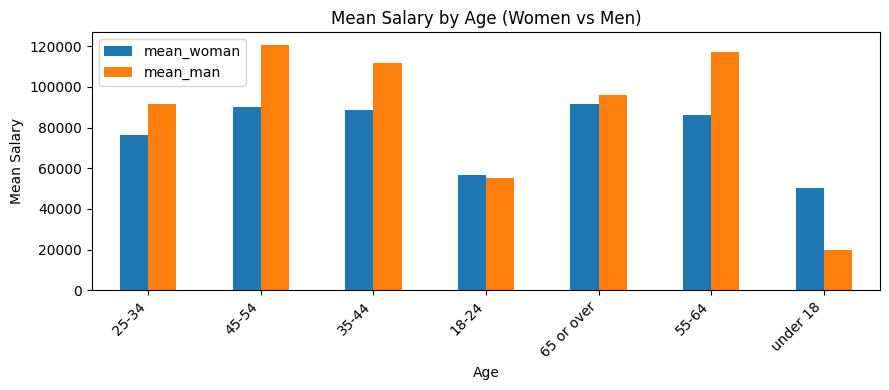

In [ ]:
category = 'Age'

analysis_by_category(category)

,Overall years of experience,mean_woman,mean_man
0,5-7 years,73988.912557,87062.489510
1,8 - 10 years,81266.231312,98631.900780
2,2 - 4 years,65003.413063,72037.775475
3,21 - 30 years,91557.732892,121893.629854
4,11 - 20 years,88156.254993,110689.870474
5,1 year or less,60761.068241,59093.574803
6,41 years or more,84667.939024,108321.589744
7,31 - 40 years,89499.108108,120387.595628


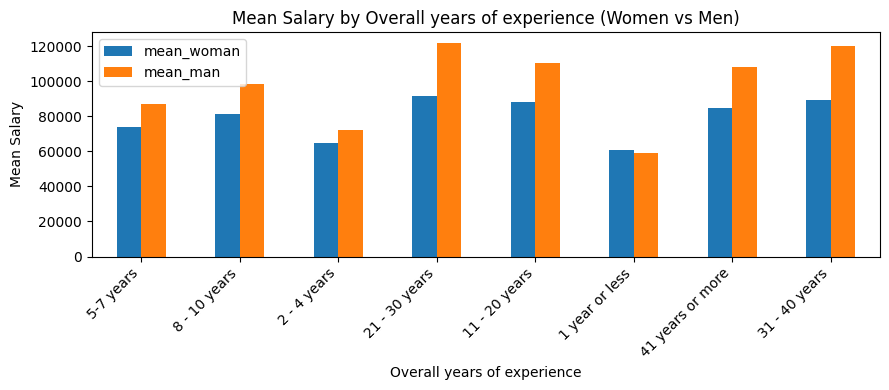

In [ ]:
if 'Overall years of experience' in df_master.columns:
  analysis_by_category('Overall years of experience')
else:
  print("'Overall years of experience' column not found.")

,Age,mean_woman,mean_man
0,25-34,76484.807342,91405.772849
1,45-54,90133.384174,120800.433036
2,35-44,88569.775864,111609.655370
3,18-24,56717.810443,55119.111913
4,65 or over,91719.726027,95966.800000
5,55-64,86332.071960,117063.005882
6,under 18,50392.100000,20000.500000


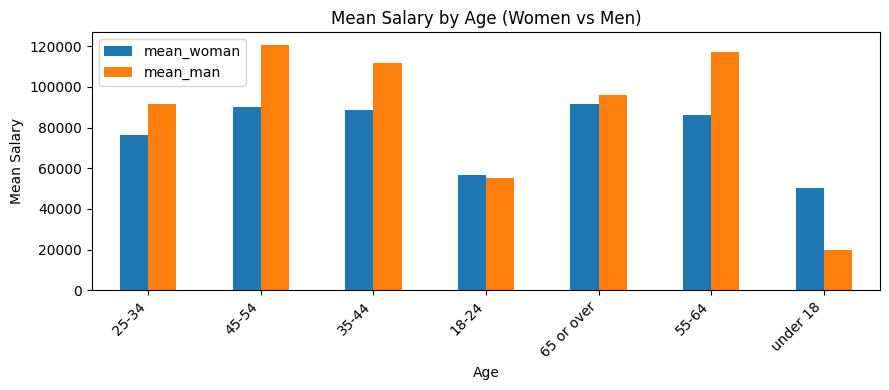

In [ ]:
if 'Age' in df_master.columns:
  analysis_by_category('Age')
else:
  print("'Age' column not found.")

In [ ]:
x = df_master[(df_master['Gender']=="Woman") & (df_master['Age']=="under 18")]
x[x['Salary'] > 60000]

,Age,Industry,Job title,Salary,Compensation,Country,State,City,Overall years of experience,Years of experience in current job,Education level,Gender,Race,Salary_USD,Compensation_USD,CGPA,Salary_month_USD,Special Bonus_GBP
10719,under 18,Nonprofits,Finance Director,118000.0,0.0,United States,District of Columbia,Washington,31 - 40 years,11 - 20 years,Master's degree,Woman,White,118000.0,0.0,3.063527,8291.666667,1099.0
25053,under 18,Law,Records manager,106000.0,3200.0,USA,Colorado,Denver,41 years or more,1 year or less,Master's degree,Woman,White,106000.0,3200.0,NaN,NaN,NaN
25601,under 18,Retail,Technology Manager,100200.0,12000.0,USA,Virginia,Richmond,21 - 30 years,21 - 30 years,Some college,Woman,"Hispanic, Latino, or Spanish origin",100200.0,12000.0,NaN,NaN,NaN


# Should I do a PhD or get a Prof cert?

This shows which job titles appear most frequently.

## PhD vs Prof Degree by Job title

In [ ]:
df_master['Job title'].value_counts()
# if 'Job title' in df_master.columns:
  # df_master['Job title'].value_counts()
# else:
  # print("'Job title' column not found.")

,count
Job title,
Software Engineer,287
Project Manager,227
Director,198
Senior Software Engineer,194
Program Manager,153
...,...
Director of Agency Services,1
Teacher - high school,1
Payroll Administration,1


,0
Software Engineer,287
Project Manager,227
Director,198
Senior Software Engineer,194
Program Manager,153
Librarian,150
Teacher,149
Manager,144
Executive Assistant,134
Product Manager,124


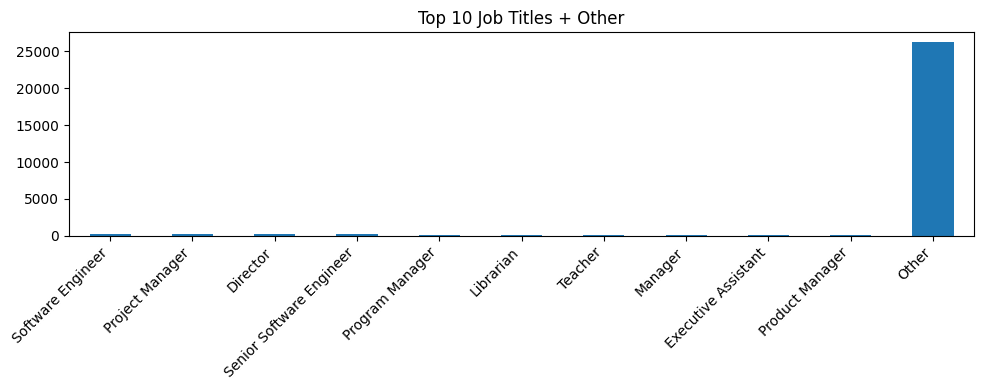

In [ ]:
if 'Job title' in df_master.columns:
  top_n = 10
  job_counts = df_master['Job title'].value_counts()

  top = job_counts.head(top_n)
  other = pd.Series({'Other': job_counts.iloc[top_n:].sum()})
  top_plus_other = pd.concat([top, other])

  display(top_plus_other)

  top_plus_other.plot(kind='bar', figsize=(10,4), title=f'Top {top_n} Job Titles + Other')
  plt.xticks(rotation=45, ha='right')
  plt.tight_layout()
  plt.show()
else:
  print("'Job title' column not found.")